# FRASCI LASSCF/LASSI/LASSIS Results

Presentation-only analysis of the saved June 16, 2026 H1 four-fragment run.
Running this notebook does **not** launch LASSCF, TrimCI, LASSI, or LASSIS.

The visuals focus on the scientifically useful small energy differences:

- start-dependent LASSCF/LASCI energies,
- LASSIS energy lowering relative to LASCI,
- final LASSIS energy as the spin expansion grows.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name != "FRASCI":
    candidate = next((p for p in [ROOT, *ROOT.parents] if (p / "FRASCI").is_dir()), None)
    if candidate is None:
        raise RuntimeError("Open this notebook from the FRASCI repository.")
    ROOT = candidate / "FRASCI"

RUN_ROOT = ROOT / "Outputs" / "lasscf" / "h1_4frag_pipeline_20260616_122809"
STARTS = ("cas", "cold", "warm")
NSPINS = (0, 1, 2)
COLORS = {"cas": "#355C7D", "cold": "#C06C84", "warm": "#6C9A8B"}

def load_json(path):
    with Path(path).open() as handle:
        return json.load(handle)

base = {
    "cas": load_json(RUN_ROOT / "cas_csf_control" / "result.json"),
    "cold": load_json(RUN_ROOT / "trimci_cold_thr0.01_dets2000_rounds4" / "result.json"),
    "warm": load_json(RUN_ROOT / "trimci_warm_from_cas_thr0.01_dets2000_rounds4" / "result.json"),
}
summaries = {
    (start, nspin): load_json(
        RUN_ROOT / f"lassi_lassis_from_{start}_ncharges_nspin{nspin}" / "summary.json"
    )
    for start in STARTS for nspin in NSPINS
}
print("Loaded:", RUN_ROOT)

Loaded: /Users/abhimuvva/Documents/Masters_Projs/Proj_Flow/FRASCI/Outputs/lasscf/h1_4frag_pipeline_20260616_122809


## Calculation status

In [2]:
lines = [
    "| Start | Method | LASSCF energy (Ha) | Status | Runtime (h) |",
    "|---|---|---:|---|---:|",
]
labels = {"cas": "CAS/CSF", "cold": "TrimCI cold", "warm": "TrimCI warm from CAS"}
for start in STARTS:
    row = base[start]
    runtime = row.get("wall_time_total", row.get("wall_clock_sec", 0.0)) / 3600
    lines.append(
        f"| {start} | {labels[start]} | {row['e_tot']:.9f} | "
        f"{row['status']} | {runtime:.2f} |"
    )
display(Markdown("\n".join(lines)))

display(Markdown(
    "> **Important:** all three orbital optimizations stopped at the configured "
    "100-cycle limit (`NOT_CONVERGED`). The comparisons below therefore describe "
    "the saved checkpoints, not fully converged LASSCF limits."
))

| Start | Method | LASSCF energy (Ha) | Status | Runtime (h) |
|---|---|---:|---|---:|
| cas | CAS/CSF | -326.929404853 | NOT_CONVERGED | 0.19 |
| cold | TrimCI cold | -326.846763327 | NOT_CONVERGED | 3.08 |
| warm | TrimCI warm from CAS | -326.855281014 | NOT_CONVERGED | 3.74 |

> **Important:** all three orbital optimizations stopped at the configured 100-cycle limit (`NOT_CONVERGED`). The comparisons below therefore describe the saved checkpoints, not fully converged LASSCF limits.

## Complete energy table

In [3]:
lines = [
    "| Start | nspin | LASSCF (Ha) | LASCI fixed-MO (Ha) | LASSI (Ha) | "
    "LASSIS (Ha) | LASSIS lowering (mHa) |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
for start in STARTS:
    for nspin in NSPINS:
        row = summaries[(start, nspin)]
        def val(key):
            value = row.get(key)
            return "—" if value is None else f"{value:.9f}"
        lines.append(
            f"| {start} | {nspin} | {row['e_lasscf']:.9f} | {row['e_lasci']:.9f} | "
            f"{val('e_lassi')} | {row['e_lassis']:.9f} | "
            f"{1000 * row['delta_e_lassis']:.3f} |"
        )
display(Markdown("\n".join(lines)))

| Start | nspin | LASSCF (Ha) | LASCI fixed-MO (Ha) | LASSI (Ha) | LASSIS (Ha) | LASSIS lowering (mHa) |
|---|---:|---:|---:|---:|---:|---:|
| cas | 0 | -326.929404853 | -326.929407868 | — | -326.952449292 | 23.041 |
| cas | 1 | -326.929404853 | -326.929407868 | — | -326.961894349 | 32.486 |
| cas | 2 | -326.929404853 | -326.929407868 | — | -326.993920794 | 64.513 |
| cold | 0 | -326.846763327 | -326.881504040 | — | -326.912007536 | 30.503 |
| cold | 1 | -326.846763327 | -326.881504040 | — | -326.913929569 | 32.426 |
| cold | 2 | -326.846763327 | -326.881504040 | — | -326.918928192 | 37.424 |
| warm | 0 | -326.855281014 | -326.926033807 | — | -326.950579764 | 24.546 |
| warm | 1 | -326.855281014 | -326.926033807 | — | -326.976577039 | 50.543 |
| warm | 2 | -326.855281014 | -326.926033807 | — | -326.991386656 | 65.353 |

## Visual 1 — checkpoint energies on a millihartree scale

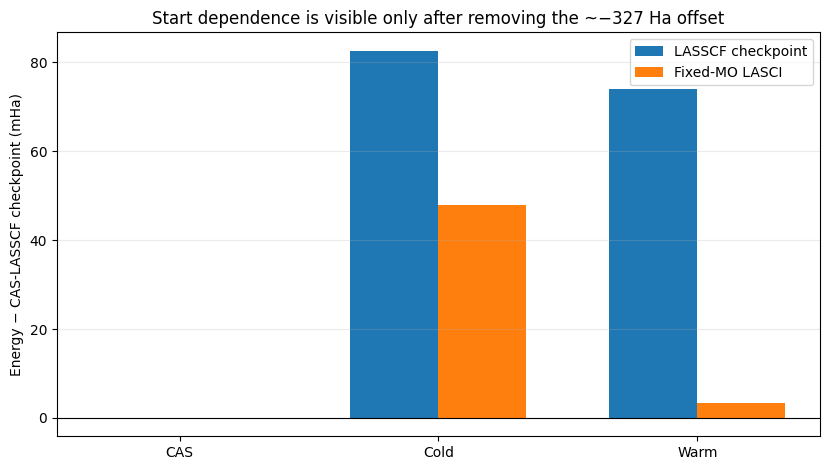

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
reference = base["cas"]["e_tot"]
x = np.arange(len(STARTS))
lasscf_gap = [(base[s]["e_tot"] - reference) * 1000 for s in STARTS]
lasci_gap = [(summaries[(s, 0)]["e_lasci"] - reference) * 1000 for s in STARTS]
width = 0.34
ax.bar(x - width / 2, lasscf_gap, width, label="LASSCF checkpoint")
ax.bar(x + width / 2, lasci_gap, width, label="Fixed-MO LASCI")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, ["CAS", "Cold", "Warm"])
ax.set_ylabel("Energy − CAS-LASSCF checkpoint (mHa)")
ax.set_title("Start dependence is visible only after removing the ~−327 Ha offset")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Visual 2 — correlation recovered by LASSIS

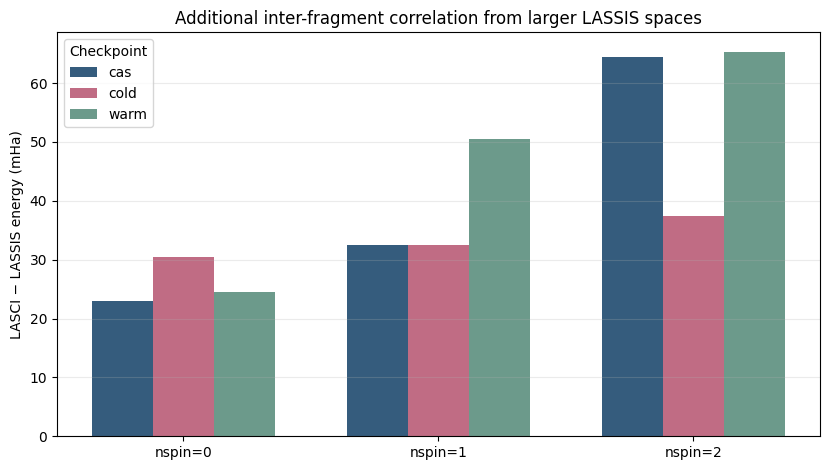

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
x = np.arange(len(NSPINS))
width = 0.24
for offset, start in zip((-width, 0, width), STARTS):
    lowering = [1000 * summaries[(start, n)]["delta_e_lassis"] for n in NSPINS]
    ax.bar(x + offset, lowering, width, label=start, color=COLORS[start])
ax.set_xticks(x, [f"nspin={n}" for n in NSPINS])
ax.set_ylabel("LASCI − LASSIS energy (mHa)")
ax.set_title("Additional inter-fragment correlation from larger LASSIS spaces")
ax.legend(title="Checkpoint")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Visual 3 — final LASSIS energies and near-degeneracies

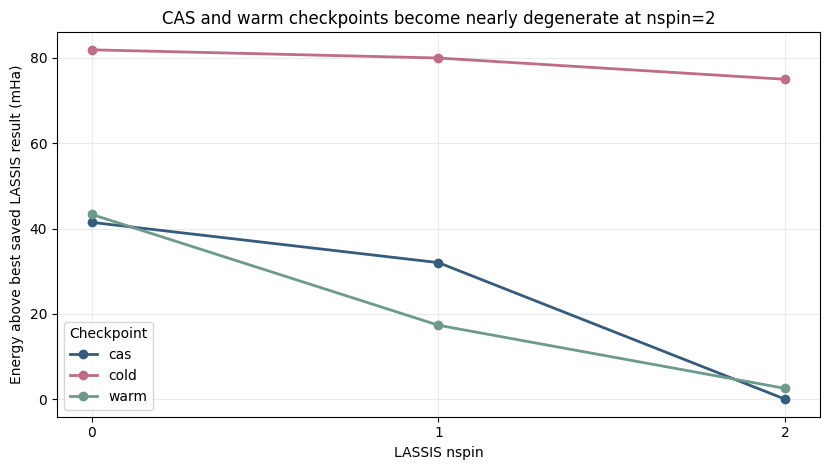

In [6]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
global_min = min(row["e_lassis"] for row in summaries.values())
for start in STARTS:
    relative = [
        1000 * (summaries[(start, n)]["e_lassis"] - global_min)
        for n in NSPINS
    ]
    ax.plot(NSPINS, relative, marker="o", linewidth=2, label=start, color=COLORS[start])
ax.set_xticks(NSPINS)
ax.set_xlabel("LASSIS nspin")
ax.set_ylabel("Energy above best saved LASSIS result (mHa)")
ax.set_title("CAS and warm checkpoints become nearly degenerate at nspin=2")
ax.legend(title="Checkpoint")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Key observations

In [7]:
best_key = min(summaries, key=lambda key: summaries[key]["e_lassis"])
best = summaries[best_key]["e_lassis"]
warm2 = summaries[("warm", 2)]["e_lassis"]
cas2 = summaries[("cas", 2)]["e_lassis"]
cold2 = summaries[("cold", 2)]["e_lassis"]

text = f'''
- **Best saved LASSIS energy:** `{best:.9f} Ha` from `{best_key[0]}`, `nspin={best_key[1]}`.
- At `nspin=2`, warm is only `{1000 * (warm2 - cas2):.3f} mHa` above CAS.
- At `nspin=2`, cold remains `{1000 * (cold2 - cas2):.3f} mHa` above CAS.
- Expanding `nspin` from 0 to 2 lowers LASSIS by
  `{1000 * (summaries[("cas", 0)]["e_lassis"] - cas2):.3f} mHa` (CAS),
  `{1000 * (summaries[("cold", 0)]["e_lassis"] - cold2):.3f} mHa` (cold), and
  `{1000 * (summaries[("warm", 0)]["e_lassis"] - warm2):.3f} mHa` (warm).
- LASSI energies are absent because the attempted LASSI state-average calculation
  failed; the files preserve that failure instead of substituting a numeric value.
'''
display(Markdown(text))


- **Best saved LASSIS energy:** `-326.993920794 Ha` from `cas`, `nspin=2`.
- At `nspin=2`, warm is only `2.534 mHa` above CAS.
- At `nspin=2`, cold remains `74.993 mHa` above CAS.
- Expanding `nspin` from 0 to 2 lowers LASSIS by
  `41.472 mHa` (CAS),
  `6.921 mHa` (cold), and
  `40.807 mHa` (warm).
- LASSI energies are absent because the attempted LASSI state-average calculation
  failed; the files preserve that failure instead of substituting a numeric value.
